<a href="https://colab.research.google.com/github/NMNl27/Malaria_Phases_Machine-learning/blob/main/ML_Malaria_Phases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.layers import *
from keras.models import Sequential
import warnings
warnings.filterwarnings('ignore')
import os
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Read data

In [ ]:
train_path = '/content/drive/MyDrive/Colab Notebooks/Malaria-phases/Train'
test_path = '/content/drive/MyDrive/Colab Notebooks/Malaria-phases/Test'

In [ ]:
img_classes = os.listdir('/content/drive/MyDrive/Colab Notebooks/Malaria-phases/Test')
print(f"Classes of images is: {img_classes}")

Classes of images is: ['gametocyte', 'ring form', 'trophozoite', 'Schizont']


# Plot image from each class.

In [ ]:
import os

# ตรวจสอบว่าเส้นทางที่ให้มาใน `train_path` มีอยู่หรือไม่
train_path = '/content/drive/MyDrive/Colab Notebooks/Malaria-phases/Test'
print(os.listdir(train_path))


['gametocyte', 'ring form', 'trophozoite', 'Schizont']


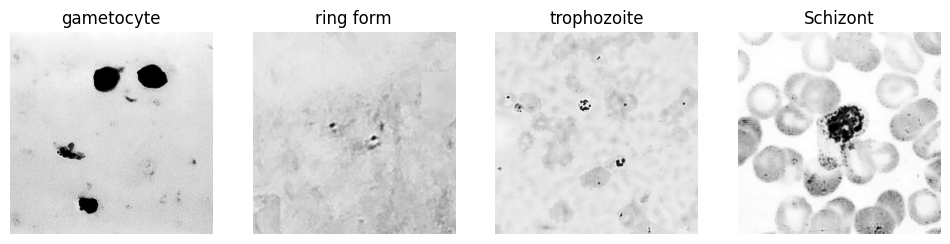

In [ ]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def plot_image(img_classes, train_path):
    plt.figure(figsize=(12, 12))

    # จำกัดการแสดงภาพสูงสุด 4 ภาพ
    for i, kind in enumerate(img_classes[:4]):
        img_path = os.path.join(train_path, kind)
        image_in_folder = os.listdir(img_path)

        # ข้ามโฟลเดอร์ว่าง
        if not image_in_folder:
            continue

        # เลือกภาพแรกจากโฟลเดอร์
        first_img = image_in_folder[0]
        first_image_path = os.path.join(img_path, first_img)

        # โหลดและแสดงภาพ
        img = image.load_img(first_image_path)
        img_array = image.img_to_array(img) / 255.0

        # แสดงผล
        plt.subplot(1, min(4, len(img_classes)), i + 1)  # เปลี่ยนจาก 3 เป็น 4
        plt.imshow(img_array)
        plt.title(kind)
        plt.axis('off')

    plt.show()

train_path = '/content/drive/MyDrive/Colab Notebooks/Malaria-phases/Test'
img_classes = os.listdir(train_path)

plot_image(img_classes, train_path)

In [ ]:
#ทำการ preprocessing
data_generator = ImageDataGenerator(rescale=1/255)

In [ ]:
train_data = data_generator.flow_from_directory(
    train_path,                   # เส้นทางของโฟลเดอร์ที่เก็บข้อมูลฝึก (train data)
    target_size=(224, 224),       # ขนาดภาพที่ต้องการ (เช่น 224x224) ก่อนที่จะป้อนเข้าสู่โมเดล
    batch_size=10,                # จำนวนภาพในแต่ละ batch
)

Found 42 images belonging to 4 classes.


In [ ]:
import os
test_path = '/content/drive/MyDrive/Colab Notebooks/Malaria-phases/Test'
print(os.listdir(test_path))  # ตรวจสอบเนื้อหาของโฟลเดอร์


['gametocyte', 'ring form', 'trophozoite', 'Schizont']


In [ ]:
test_data = data_generator.flow_from_directory(
    test_path,                  # เส้นทางของโฟลเดอร์ที่เก็บข้อมูลทดสอบ
    target_size=(224, 224),     # ขนาดภาพที่ต้องการ (เช่น 224x224) ก่อนที่จะป้อนเข้าสู่โมเดล
    batch_size=10,              # จำนวนภาพในแต่ละ batch
)


Found 42 images belonging to 4 classes.


# Build CNN Model

In [ ]:
#CNN Model
model = Sequential()

#add Conv layer with filters, kernel, padding, activation, input shape
model.add(Conv2D(filters = 32, kernel_size = 3, padding = 'same',
                activation = 'relu', input_shape = [224,224,3])) #feature extraction

#add pooling layer ---> dimensionality reduction
model.add(MaxPooling2D(pool_size = (2,2)))

#add batch normalization layer
model.add(BatchNormalization())

#add Conv layer with filters, kernel, padding, activation
model.add(Conv2D(filters = 64, kernel_size = 3, padding = 'same',activation = 'relu')) #feature extraction

#add pooling layer ---> dimensionality reduction
model.add(MaxPooling2D())

#add batch normalization layer
#model.add(BatchNormalization())

#add Conv layer with filters, kernel, padding, activation
model.add(Conv2D(filters = 128, kernel_size = 3, padding = 'same',activation = 'relu')) #feature extraction

#add pooling layer ---> dimensionality reduction
model.add(MaxPooling2D())

#add dropout layer
model.add(Dropout(0.2))

#add Flatten layer ---> 1D
model.add(Flatten())

#add Fully Connnected Layers
model.add(Dense(128, activation = 'relu'))
model.add(Dense(128, activation = 'relu'))

#add output layer
model.add(Dense(4, activation = 'softmax')) #4 classes

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,955,588 (49.42 MB)

 Trainable params: 12,955,524 (49.42 MB)

 Non-trainable params: 64 (256.00 B)

In [ ]:
# คอมไพล์โมเดล
model.compile(optimizer = 'adam',
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])

In [ ]:
history = model.fit(train_data,  # train data generator
                    epochs = 10,  # จำนวนรอบที่ฝึกโมเดล
                    validation_data = test_data)  # ข้อมูลทดสอบเพื่อประเมินผล


Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.2619 - loss: 7.5966 - val_accuracy: 0.2143 - val_loss: 1.4129
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.4762 - loss: 1.1982 - val_accuracy: 0.4762 - val_loss: 1.3791
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.6905 - loss: 1.1429 - val_accuracy: 0.6429 - val_loss: 1.3776
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8333 - loss: 0.9188 - val_accuracy: 0.2619 - val_loss: 1.3648
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.9286 - loss: 0.5192 - val_accuracy: 0.2619 - val_loss: 1.3597
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9286 - loss: 0.3042 - val_accuracy: 0.4048 - val_loss: 1.4330
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9048 - loss: 0.2822 - val_accuracy: 0.2143 - val_loss: 1.3405
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.8571 - loss: 0.3581 - val_accuracy: 0.7619 - val_loss: 1.1836
Epoch 9/10
5/

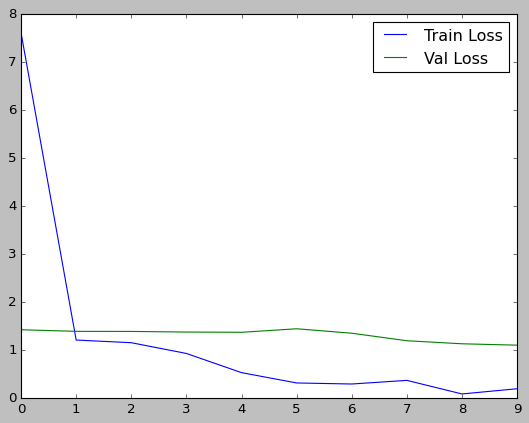

In [ ]:
# visualization for loss
plt.style.use('classic')
plt.plot(history.history['loss'], label='Train Loss')  # ใช้ 'history' แทน 'model_history'
plt.plot(history.history['val_loss'], label='Val Loss')  # ใช้ 'history' แทน 'model_history'
plt.legend()
plt.show()


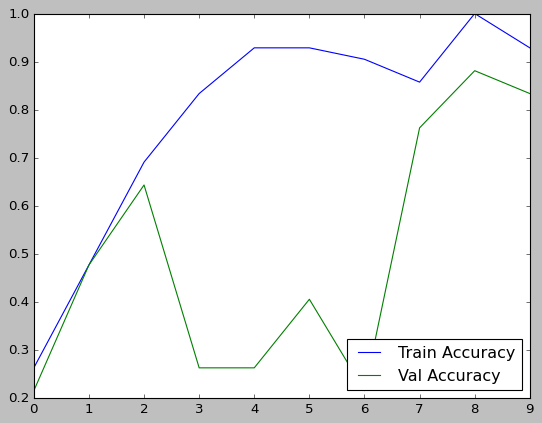

In [ ]:
#visualization for loss
plt.style.use('classic')
plt.plot(history.history['accuracy'] , label='Train Accuracy')
plt.plot(history.history['val_accuracy'] , label='Val Accuracy')
plt.legend(loc='lower right')
plt.show()

In [ ]:
# ประเมินโมเดลบนชุดข้อมูลทดสอบ
test_loss, test_acc = model.evaluate(test_data)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 507ms/step - accuracy: 0.8333 - loss: 1.0915


In [ ]:
# ประเมินโมเดลบนชุดข้อมูลทดสอบ
train_loss, train_acc = model.evaluate(train_data)

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 638ms/step - accuracy: 0.8333 - loss: 1.0915


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# ทำนายผลลัพธ์จากข้อมูลทดสอบ
y_pred = model.predict(test_data)  # ทำนายผลจากชุดข้อมูลทดสอบ
y_true = test_data.classes  # ค่าความจริงจากชุดข้อมูลทดสอบ (เช่น labels)

# คำนวณ confusion matrix
cm = confusion_matrix(y_true, np.argmax(y_pred, axis=1))

# คำนวณ accuracy ของแต่ละคลาส
class_accuracy = cm.diagonal() / cm.sum(axis=1)

# แสดงผล accuracy ของแต่ละคลาส
class_labels = ['Ring Form', 'Gametocyte', 'Trophozoite', 'Schizont']  # คลาสของคุณ
for i, accuracy in enumerate(class_accuracy):
    print(f"Accuracy of {class_labels[i]}: {accuracy * 100:.2f}%")


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 494ms/step
Accuracy of Ring Form: 18.18%
Accuracy of Gametocyte: 44.44%
Accuracy of Trophozoite: 25.00%
Accuracy of Schizont: 60.00%


In [ ]:
#save model
model.save('Malaria-Phases.keras')

**การนำโมเดลมาใช้งาน**

Saving thumb_400.jpg to thumb_400.jpg


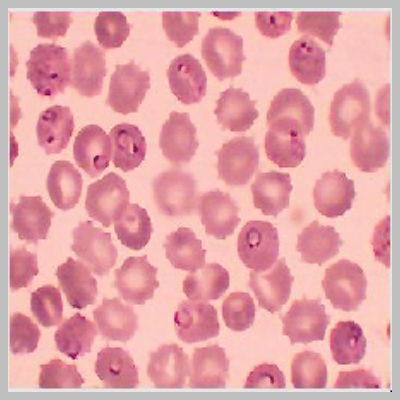

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
Ring Form: 0.190534
Gametocyte: 0.299703
Trophozoite: 0.226330
schizont: 0.283432


In [ ]:
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
from keras.preprocessing import image
from keras.models import load_model

# อัพโหลดไฟล์รูปภาพ
uploaded = files.upload()

# โหลดโมเดล
model = load_model('Malaria-Phases.keras')

# โหลดและแสดงภาพ
img_path = next(iter(uploaded))
img = image.load_img(img_path, target_size=(224, 224))
plt.imshow(img)
plt.axis('off')
plt.show()

# แปลงภาพเป็นอาเรย์
img_array = image.img_to_array(img) / 255
img_array = np.expand_dims(img_array, axis=0)

# ทำนายผล
prediction = model.predict(img_array)

# แสดงผลลัพธ์
class_labels = ['Ring Form', 'Gametocyte', 'Trophozoite', 'schizont']
for i, prob in enumerate(prediction[0]):
    print(f"{class_labels[i]}: {prob:.6f}")

predicted_class = class_labels[np.argmax(prediction)]
